# Feature Engineering

---

1. Import packages
2. Load data
3. Feature engineering

---

## 1. Import packages

In [1]:
import pandas as pd

---
## 2. Load data

In [2]:
df = pd.read_csv('clean_data_after_eda.csv')
df["date_activ"] = pd.to_datetime(df["date_activ"], format='%Y-%m-%d')
df["date_end"] = pd.to_datetime(df["date_end"], format='%Y-%m-%d')
df["date_modif_prod"] = pd.to_datetime(df["date_modif_prod"], format='%Y-%m-%d')
df["date_renewal"] = pd.to_datetime(df["date_renewal"], format='%Y-%m-%d')

In [3]:
df.head(3)

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,var_6m_price_off_peak_var,var_6m_price_peak_var,var_6m_price_mid_peak_var,var_6m_price_off_peak_fix,var_6m_price_peak_fix,var_6m_price_mid_peak_fix,var_6m_price_off_peak,var_6m_price_peak,var_6m_price_mid_peak,churn
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,0.000131,4.100838e-05,0.000908,2.086294,99.530517,44.235794,2.086425,9.953056e+01,44.236702,1
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,0.000003,1.217891e-03,0.000000,0.009482,0.000000,0.000000,0.009485,1.217891e-03,0.000000,0
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,...,0.000004,9.450150e-08,0.000000,0.000000,0.000000,0.000000,0.000004,9.450150e-08,0.000000,0


---

## 3. Feature engineering

### Difference between off-peak prices in December and preceding January

Below is the code created by your colleague to calculate the feature described above. Use this code to re-create this feature and then think about ways to build on this feature to create features with a higher predictive power.

In [4]:
price_df = pd.read_csv('price_data.csv')
price_df["price_date"] = pd.to_datetime(price_df["price_date"], format='%Y-%m-%d')
price_df.head()

,id,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
0,038af19179925da21a25619c5a24b745,2015-01-01,0.151367,0.0,0.0,44.266931,0.0,0.0
1,038af19179925da21a25619c5a24b745,2015-02-01,0.151367,0.0,0.0,44.266931,0.0,0.0
2,038af19179925da21a25619c5a24b745,2015-03-01,0.151367,0.0,0.0,44.266931,0.0,0.0
3,038af19179925da21a25619c5a24b745,2015-04-01,0.149626,0.0,0.0,44.266931,0.0,0.0
4,038af19179925da21a25619c5a24b745,2015-05-01,0.149626,0.0,0.0,44.266931,0.0,0.0


In [15]:
monthly_price_by_id = price_df.groupby(['id', 'price_date']).agg({'price_off_peak_var': 'mean', 'price_off_peak_fix': 'mean'}).reset_index()

jan_prices = monthly_price_by_id.groupby('id').first().reset_index()
dec_prices = monthly_price_by_id.groupby('id').last().reset_index()

diff = pd.merge(dec_prices.rename(columns={'price_off_peak_var': 'dec_1', 'price_off_peak_fix': 'dec_2'}), jan_prices.drop(columns='price_date'), on='id')
diff['offpeak_diff_dec_january_energy'] = diff['dec_1'] - diff['price_off_peak_var']
diff['offpeak_diff_dec_january_power'] = diff['dec_2'] - diff['price_off_peak_fix']
diff = diff[['id', 'offpeak_diff_dec_january_energy','offpeak_diff_dec_january_power']]
diff.head()

,id,offpeak_diff_dec_january_energy,offpeak_diff_dec_january_power
0,0002203ffbb812588b632b9e628cc38d,-0.006192,0.162916
1,0004351ebdd665e6ee664792efc4fd13,-0.004104,0.177779
2,0010bcc39e42b3c2131ed2ce55246e3c,0.050443,1.500000
3,0010ee3855fdea87602a5b7aba8e42de,-0.010018,0.162916
4,00114d74e963e47177db89bc70108537,-0.003994,-0.000001


Now it is time to get creative and to conduct some of your own feature engineering! Have fun with it, explore different ideas and try to create as many as you can!

In [16]:
df['tenure_years'] = (
    df['date_end'] - df['date_activ']
).dt.days / 365
df.head(2)

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,var_6m_price_off_peak,var_6m_price_peak,var_6m_price_mid_peak,churn,tenure_years,renewal_gap,cons_per_month,margin_ratio,cons_ratio,total_energy_price
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,2.086425,99.530558,44.236702,1,3.002740,358,0.000000,0.962179,0.0,0.212623
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,0.009485,0.001218,0.000000,0,7.030137,365,388.333333,0.942463,0.0,0.145711


In [17]:
df['renewal_gap'] = (
    df['date_end'] - df['date_renewal']
).dt.days
df.head(3)

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,var_6m_price_off_peak,var_6m_price_peak,var_6m_price_mid_peak,churn,tenure_years,renewal_gap,cons_per_month,margin_ratio,cons_ratio,total_energy_price
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,2.086425,9.953056e+01,44.236702,1,3.002740,358,0.000000,0.962179,0.0,0.212623
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,0.009485,1.217891e-03,0.000000,0,7.030137,365,388.333333,0.942463,0.0,0.145711
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,...,0.000004,9.450150e-08,0.000000,0,6.005479,365,45.333333,0.966216,0.0,0.253693


In [18]:
df['cons_per_month'] = (
    df['cons_12m'] / 12
)
df.sample(4)

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,var_6m_price_off_peak,var_6m_price_peak,var_6m_price_mid_peak,churn,tenure_years,renewal_gap,cons_per_month,margin_ratio,cons_ratio,total_energy_price
7596,895c327554c85db7162af80255a0af25,usilxuppasemubllopkaafesmlibmsdf,12963,0,0,2012-11-14,2016-11-14,2015-11-01,2015-11-15,1312.90,...,0.007091,2.551248e-03,1.132660e-03,0,4.002740,365,1080.250000,0.843750,0.000000,0.216762
13904,74efb6c12462e4eb5e0cd7ddefd4217a,lmkebamcaaclubfxadlmueccxoimlema,15685,0,1717,2012-12-05,2016-12-04,2015-05-24,2015-12-06,1609.28,...,0.000011,2.873184e-06,4.860000e-10,0,4.000000,364,1307.083333,0.590164,1.312608,0.215360
13060,624b0339bc17c23eb074de76f0f01a1b,foosdfpfkusacimwkcsosbicdxkicaua,22992,0,1857,2012-10-16,2016-10-16,2015-08-27,2015-10-18,821.24,...,0.640824,1.217891e-03,0.000000e+00,0,4.002740,364,1916.000000,0.947699,0.968701,0.143460
4306,db7ded23fe7376853f0d2aea6334c59a,foosdfpfkusacimwkcsosbicdxkicaua,13976,7257,1943,2009-11-02,2016-11-02,2015-09-18,2015-11-04,1821.93,...,0.005272,2.833842e-07,0.000000e+00,0,7.005479,364,1164.666667,0.848024,1.666857,0.250251


In [ ]:
df['margin_ratio'] = (
    df['margin_net_pow_ele']
    / (df['margin_gross_pow_ele'] + 1)
)
df.head(4)

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,var_6m_price_off_peak,var_6m_price_peak,var_6m_price_mid_peak,churn,tenure_years,renewal_gap,cons_per_month,margin_ratio,cons_ratio,total_energy_price
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,2.086425,9.953056e+01,44.236702,1,3.002740,358,0.000000,0.962179,0.0,0.212623
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,0.009485,1.217891e-03,0.000000,0,7.030137,365,388.333333,0.942463,0.0,0.145711
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,...,0.000004,9.450150e-08,0.000000,0,6.005479,365,45.333333,0.966216,0.0,0.253693
3,bba03439a292a1e166f80264c16191cb,lmkebamcaaclubfxadlmueccxoimlema,1584,0,0,2010-03-30,2016-03-30,2010-03-30,2015-03-31,240.04,...,0.000003,0.000000e+00,0.000000,0,6.005479,365,132.000000,0.967969,0.0,0.146694


In [19]:
df['total_energy_price'] = (
    df['forecast_price_energy_peak']
    + df['forecast_price_energy_off_peak']
)
df.sample(5)

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,var_6m_price_off_peak,var_6m_price_peak,var_6m_price_mid_peak,churn,tenure_years,renewal_gap,cons_per_month,margin_ratio,cons_ratio,total_energy_price
12589,3784d88a062c93d684e56ac0dce41dba,lmkebamcaaclubfxadlmueccxoimlema,0,0,0,2010-10-25,2016-10-25,2010-10-25,2015-10-28,0.00,...,1.264732,1.014319e-06,0.0,0,6.005479,363,0.000000,0.955830,0.000000,0.257844
11556,b5a78d4d9d83c271129f01c49658f461,lmkebamcaaclubfxadlmueccxoimlema,12771,0,996,2009-12-01,2016-05-19,2015-05-19,2014-12-19,348.28,...,0.000003,0.000000e+00,0.0,0,6.468493,517,1064.250000,0.979262,0.934992,0.199230
6490,9087e849d94f7baec57291470d0822a3,foosdfpfkusacimwkcsosbicdxkicaua,7592,0,1557,2011-11-11,2016-11-11,2011-11-11,2015-11-12,1127.81,...,0.231197,0.000000e+00,0.0,1,5.005479,365,632.666667,0.944196,2.457128,0.147506
9794,393babbab07d4a365c7d74e1af726428,MISSING,7054,0,0,2004-08-03,2016-08-03,2004-08-03,2015-08-04,1051.37,...,0.008431,0.000000e+00,0.0,0,12.008219,365,587.833333,0.940191,0.000000,0.144902
762,e1881b8cfc03480d204eb857c9286fc1,foosdfpfkusacimwkcsosbicdxkicaua,6132,0,2343,2010-01-21,2017-01-21,2014-08-26,2016-01-22,699.01,...,0.000004,9.450150e-08,0.0,0,7.005479,365,511.000000,0.963018,4.576172,0.253693


In [20]:
df['cons_ratio'] = (
    df['cons_last_month']
    / (df['cons_12m']/12 + 1)
)
df.sample(6)

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,var_6m_price_off_peak,var_6m_price_peak,var_6m_price_mid_peak,churn,tenure_years,renewal_gap,cons_per_month,margin_ratio,cons_ratio,total_energy_price
9962,54f8ca2ab1f8fadc6c380285df40a329,MISSING,50362,0,12680,2004-07-13,2016-07-13,2004-07-13,2015-07-14,5008.03,...,0.004431,0.001593,7.107480e-04,1,12.008219,365,4196.833333,0.916318,3.020606,0.214011
8242,96ecc5e1bc91e0e2b09b97d50016b6c2,foosdfpfkusacimwkcsosbicdxkicaua,19913,0,2683,2010-03-26,2016-03-26,2010-03-26,2015-03-29,0.00,...,0.000011,0.000003,4.860000e-10,0,6.005479,363,1659.416667,0.973801,1.615859,0.217482
5979,60b82b235f7e502de3b25d65908a2b1c,MISSING,26274,0,1572,2007-04-04,2016-04-04,2007-04-04,2015-04-05,839.31,...,0.000011,0.000003,4.860000e-10,0,9.008219,365,2189.500000,0.981301,0.717644,0.214011
3654,eda05d0cf444e9f4c219ab63adcf0ffa,MISSING,31638,0,3106,2003-08-08,2016-08-08,2015-07-11,2015-08-09,2829.50,...,0.007088,0.002550,1.135052e-03,0,13.010959,365,2636.500000,0.911661,1.177630,0.210552
11671,2299efe7c042e900e11ef8436a65f4fe,lmkebamcaaclubfxadlmueccxoimlema,60246,0,9638,2010-02-01,2016-02-01,2015-12-15,2015-02-02,6525.40,...,0.000005,0.000001,0.000000e+00,0,6.002740,364,5020.500000,0.968944,1.919347,0.242705
12992,f49c696e0e3507f894f2f911d8553407,foosdfpfkusacimwkcsosbicdxkicaua,3423,0,423,2011-01-18,2016-02-24,2015-06-23,2015-02-26,303.58,...,0.000011,0.000003,4.860000e-10,0,5.104110,363,285.250000,0.973985,1.477729,0.216915


In [23]:
corr = df.corr(numeric_only=True)

corr['churn'].sort_values(
ascending=False
).head(20)

churn                          1.000000
margin_net_pow_ele             0.095772
margin_gross_pow_ele           0.095725
forecast_meter_rent_12m        0.044245
net_margin                     0.041135
pow_max                        0.030362
forecast_price_energy_peak     0.029315
var_year_price_off_peak_var    0.028646
total_energy_price             0.024882
var_6m_price_off_peak_var      0.019628
var_year_price_off_peak        0.018930
var_year_price_off_peak_fix    0.018930
forecast_discount_energy       0.017026
forecast_price_pow_off_peak    0.014778
var_year_price_peak_fix        0.014674
var_year_price_peak            0.014674
var_6m_price_peak              0.013521
var_6m_price_peak_fix          0.013521
forecast_cons_12m              0.012949
var_6m_price_off_peak          0.011891
Name: churn, dtype: float64

<Axes: >

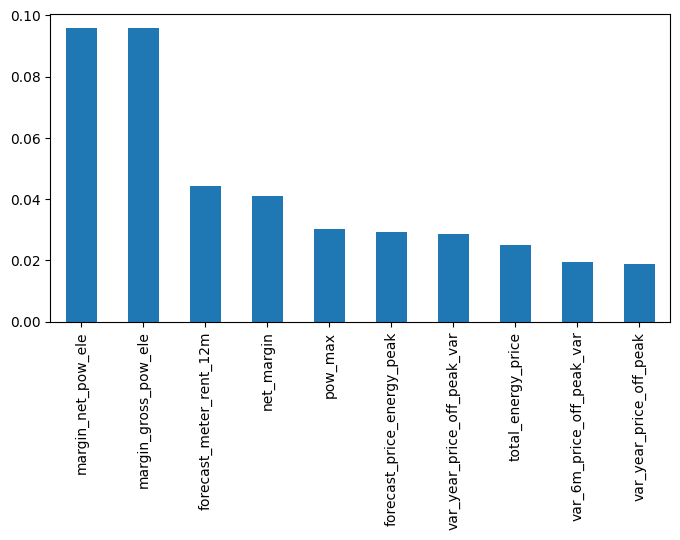

In [24]:
top_features = corr['churn']\
.sort_values(ascending=False)[1:11]

top_features.plot(
kind='bar',
figsize=(8,4)
)

Feature Engineering Summary

To improve the predictive power of the churn model, additional features were created from the available customer and pricing data.

The first engineered features measured the difference between December and January off-peak energy and power prices. These features were designed to capture changes in pricing over time and test whether price increases influence customer churn.

Additional features included customer tenure, renewal-related variables, consumption-based metrics, and margin-related indicators. These features help represent customer loyalty, contract behavior, energy usage patterns, and profitability more effectively than the original variables alone.

Feature engineering is an important step because it transforms raw data into more meaningful information that can improve model performance and provide deeper insights into the factors that drive customer churn.

Key Findings

1. Customer tenure and renewal-related variables provide useful information about churn behavior.

2. Price change features capture fluctuations in energy pricing and may help identify customers sensitive to price increases.

3. Consumption-based features provide a better representation of customer usage patterns than raw annual consumption values.

4. Engineered features are expected to improve model performance compared with the original dataset.